# Bearing Anomaly Detection using NASA IMS Dataset

## Objective
To detect early-stage bearing anomalies using unsupervised machine learning and deep learning models on vibration data.

### Dataset Loading

In [189]:
import os
import pandas as pd
import numpy as np

data_dir = r"C:\Projects\BTP_Predictive_Maintenance\data\archive (3)\2nd_test\2nd_test"

data_frames = []

for filename in sorted(os.listdir(data_dir)):
    dataset = pd.read_csv(os.path.join(data_dir, filename), sep='\t', header=None)
    dataset_mean_abs = dataset.abs().mean().values #Feature extraction: Mean Absolute Value (MAV)
    df = pd.DataFrame(dataset_mean_abs.reshape(1, 4),
                      index=[filename],
                      columns=['Bearing 1', 'Bearing 2', 'Bearing 3', 'Bearing 4'])
    data_frames.append(df)

merged_data = pd.concat(data_frames)

### Index Transformation

In [190]:
# transform index to datetime format
merged_data.index = pd.to_datetime(merged_data.index, format='%Y.%m.%d.%H.%M.%S')

merged_data = merged_data.sort_index()
#merged_data.to_csv('merged_Dataset_BearingTest_2.csv')


In [191]:
merged_data.sample(10)

,Bearing 1,Bearing 2,Bearing 3,Bearing 4
2004-02-17 03:12:39,0.080186,0.073990,0.076042,0.045639
2004-02-18 12:32:39,0.115960,0.082557,0.084782,0.053490
2004-02-16 05:22:39,0.068130,0.074010,0.075499,0.044563
2004-02-19 06:22:39,0.001168,0.000767,0.000716,0.001699
2004-02-16 02:02:39,0.062994,0.074505,0.076728,0.045015
2004-02-13 04:42:39,0.061042,0.075411,0.079810,0.044983
2004-02-15 05:52:39,0.060828,0.073486,0.075211,0.044238
2004-02-15 23:52:39,0.064163,0.074462,0.077924,0.044518
2004-02-13 08:52:39,0.061009,0.076224,0.080195,0.044106
2004-02-19 02:02:39,0.162949,0.096347,0.096861,0.071857


In [192]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(merged_data)

print("Scaler expects:", scaler.n_features_in_)

Scaler expects: 4


## Feature Engineering
Statistical and normalized features are extracted to support anomaly detection models.

In [193]:
#Statistical features for each bearings
'''
Findings: The high skew & kurtosis values of both bearings 1 & 4 indicates that there might be some anomalies in those
bearings a and we should pay close attention to those while analysing further
'''

def extract_statistical_features(df):
    features = pd.DataFrame()
    features['mean'] = merged_data.mean(axis=0)
    features['std'] = merged_data.std(axis=0)
    features['skew'] = merged_data.skew(axis=0)
    features['kurtosis'] = merged_data.kurtosis(axis=0)
    features['max'] = merged_data.max(axis=0)
    features['min'] = merged_data.min(axis=0)
    features['range'] = features['max'] - features['min']
    return features

stat_features = pd.DataFrame(extract_statistical_features(merged_data))
#print(stat_features)
stat_features

,mean,std,skew,kurtosis,max,min,range
Bearing 1,0.080905,0.040171,4.187848,24.726709,0.453318,0.001168,0.452149
Bearing 2,0.078532,0.011779,3.106748,19.736561,0.161011,0.000767,0.160244
Bearing 3,0.081356,0.011596,2.484602,15.261470,0.151296,0.000716,0.150579
Bearing 4,0.047822,0.009541,3.729213,20.337947,0.119042,0.001699,0.117344


### Data Normalization

In [194]:
# Z-score normalization
merged_data_normalized = merged_data.apply(lambda x: (x - x.mean()) / x.std())

In [195]:
'''from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(merged_data)'''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(merged_data.values)

In [196]:
features_scaled = scaler.transform(features.reshape(1,-1))

# Anomaly Detection Model


### Prepare Data for Temporal Models (LSTM)
Static models detect anomalies at individual timestamps, whereas the LSTM Autoencoder captures temporal degradation patterns, leading to more stable and meaningful anomaly detection.

In [197]:
def create_sequences(data, window_size=20):
    sequences = []
    for i in range(len(data) - window_size):
        seq = data.iloc[i:i+window_size].values
        sequences.append(seq)
    return np.array(sequences)

X_seq = create_sequences(merged_data_normalized, window_size=20)

X_seq.shape

(964, 20, 4)

In [198]:
train_size = int(0.7 * len(X_seq))
X_train = X_seq[:train_size]
X_test  = X_seq[train_size:]


## LSTM Auto-Encoder - Model

In [199]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

timesteps = X_train.shape[1]
features = X_train.shape[2]

inputs = Input(shape=(timesteps, features))

encoded = LSTM(64, activation='tanh', return_sequences=False)(inputs)
encoded = RepeatVector(timesteps)(encoded)

decoded = LSTM(64, activation='tanh', return_sequences=True)(encoded)
decoded = TimeDistributed(Dense(features))(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 20, 4)]           0         
                                                                 
 lstm_6 (LSTM)               (None, 64)                17664     
                                                                 
 repeat_vector_3 (RepeatVect  (None, 20, 64)           0         
 or)                                                             
                                                                 
 lstm_7 (LSTM)               (None, 20, 64)            33024     
                                                                 
 time_distributed_3 (TimeDis  (None, 20, 4)            260       
 tributed)                                                       
                                                                 
Total params: 50,948
Trainable params: 50,948
Non-trainable

### Model Training

In [200]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/30
19/19 [==============================] - 13s 114ms/step - loss: 0.0347 - val_loss: 0.0194
Epoch 2/30
19/19 [==============================] - 1s 30ms/step - loss: 0.0212 - val_loss: 0.0174
Epoch 3/30
19/19 [==============================] - 1s 27ms/step - loss: 0.0194 - val_loss: 0.0199
Epoch 4/30
19/19 [==============================] - 1s 27ms/step - loss: 0.0125 - val_loss: 0.0130
Epoch 5/30
19/19 [==============================] - 1s 27ms/step - loss: 0.0100 - val_loss: 0.0110
Epoch 6/30
19/19 [==============================] - 1s 26ms/step - loss: 0.0086 - val_loss: 0.0096
Epoch 7/30
19/19 [==============================] - 1s 29ms/step - loss: 0.0076 - val_loss: 0.0084
Epoch 8/30
19/19 [==============================] - 0s 24ms/step - loss: 0.0077 - val_loss: 0.0085
Epoch 9/30
19/19 [==============================] - 0s 24ms/step - loss: 0.0073 - val_loss: 0.0071
Epoch 10/30
19/19 [==============================] - 0s 25ms/step - loss: 0.0073 - val_loss: 0.0076
Epoch 1

In [201]:
X_pred = autoencoder.predict(X_test)

reconstruction_error = np.mean(
    np.square(X_test - X_pred), axis=(1,2)
)


scores = reconstruction_error
scores

10/10 [==============================] - 1s 9ms/step


array([6.69933141e-03, 6.40531787e-03, 6.72551146e-03, 6.24035327e-03,
       6.45696131e-03, 6.46347494e-03, 6.34785761e-03, 7.06866248e-03,
       7.06166724e-03, 2.17037019e-02, 4.06081461e-02, 5.62904615e-02,
       6.73345453e-02, 7.55154537e-02, 8.08329543e-02, 8.42935883e-02,
       8.28743185e-02, 8.22636833e-02, 7.97675583e-02, 7.31986391e-02,
       6.73076939e-02, 5.97882564e-02, 5.05374616e-02, 4.42605176e-02,
       3.68690578e-02, 3.07467030e-02, 2.94031863e-02, 3.17660457e-02,
       3.78849648e-02, 3.99508570e-02, 3.92438747e-02, 3.82197822e-02,
       3.65467159e-02, 3.57779205e-02, 3.47704518e-02, 3.46512966e-02,
       3.67532212e-02, 3.48788062e-02, 3.59006182e-02, 3.56839360e-02,
       3.62759792e-02, 3.57467628e-02, 3.59573922e-02, 3.75755509e-02,
       3.77422271e-02, 4.15616084e-02, 4.57580247e-02, 4.58055094e-02,
       4.69132183e-02, 4.79371681e-02, 5.07298405e-02, 5.11378403e-02,
       5.05126224e-02, 4.79508753e-02, 4.71432766e-02, 4.53507398e-02,
      

In [202]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
lstm_ae_scores_norm = scaler.fit_transform(reconstruction_error.reshape(-1,1)).ravel()


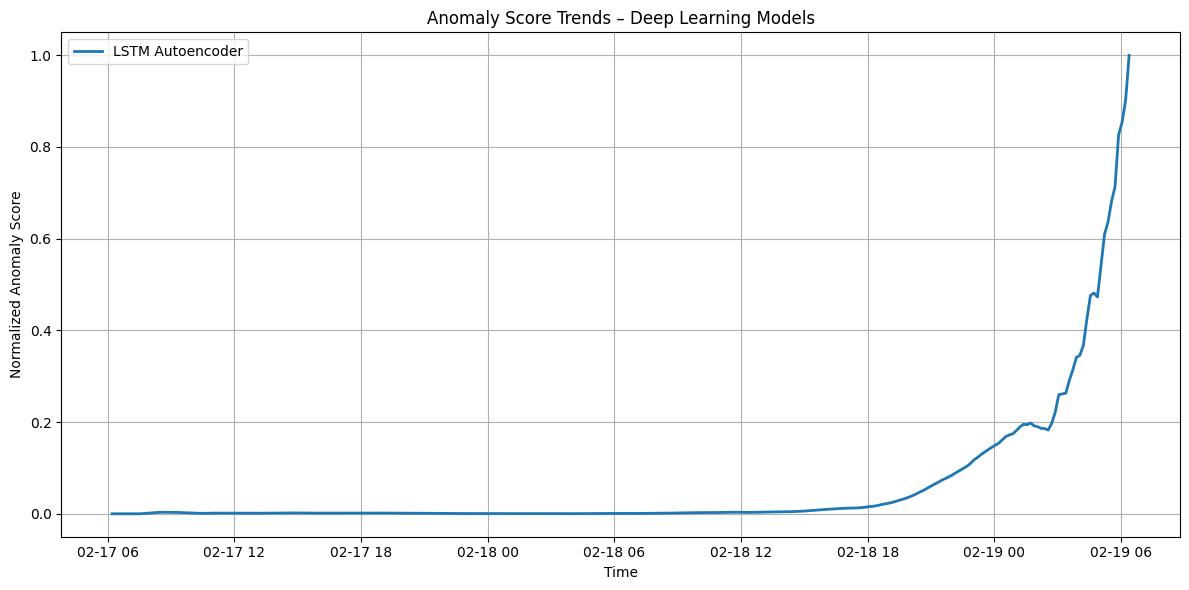

In [203]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

idx_lstm = merged_data.index[-len(lstm_ae_scores_norm):]
plt.plot(idx_lstm, lstm_ae_scores_norm, label='LSTM Autoencoder', linewidth=2)

plt.xlabel("Time")
plt.ylabel("Normalized Anomaly Score")
plt.title("Anomaly Score Trends – Deep Learning Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [204]:
import numpy as np

def compute_ttf_and_early_detection(
    scores,
    threshold_percentile=90,
    sustain_points=5,
    early_offset=20
):
    scores = np.asarray(scores)

    # Threshold
    threshold = np.percentile(scores, threshold_percentile)

    # Points exceeding threshold
    exceed_idx = np.where(scores >= threshold)[0]

    if len(exceed_idx) == 0:
        return None, None, None, threshold

    # Sustained failure detection
    failure_index = None
    for i in exceed_idx:
        if i + sustain_points < len(scores):
            if np.all(scores[i:i+sustain_points] >= threshold):
                failure_index = i
                break

    if failure_index is None:
        failure_index = exceed_idx[0]

    # Early detection
    early_index = max(0, failure_index - early_offset)

    # Time to Failure
    ttf = len(scores) - failure_index

    return ttf, failure_index, early_index, threshold


### Dynamic Threshold

In [205]:
def dynamic_threshold(scores, window_size=50, percentile=90):

    thresholds = []

    for i in range(len(scores)):

        if i < window_size:
            thresholds.append(np.nan)
            continue

        window = scores[i-window_size:i]

        threshold = np.percentile(window, percentile)

        thresholds.append(threshold)

    return np.array(thresholds)


thresholds = dynamic_threshold(scores)


In [206]:


thresholds = dynamic_threshold(scores, window_size=50, percentile=90)

anomalies = scores > thresholds

In [207]:
def compute_ttf_and_early_detection(
    scores,
    thresholds,
    sustain_points=5,
    early_offset=20
):

    scores = np.asarray(scores)

    exceed_idx = np.where(scores >= thresholds)[0]

    if len(exceed_idx) == 0:
        return None, None, None

    failure_index = None

    for i in exceed_idx:

        if i + sustain_points < len(scores):

            if np.all(scores[i:i+sustain_points] >= thresholds[i:i+sustain_points]):
                failure_index = i
                break

    if failure_index is None:
        failure_index = exceed_idx[0]

    early_index = max(0, failure_index - early_offset)

    ttf = len(scores) - failure_index

    return ttf, failure_index, early_index


ttf, failure_idx, early_idx = compute_ttf_and_early_detection(
    scores,
    thresholds
)


print("Failure Index:", failure_idx)
print("Early Warning Index:", early_idx)
print("Estimated TTF:", ttf)


Failure Index: 149
Early Warning Index: 129
Estimated TTF: 141


Text(0, 0.5, 'Anomaly Score')

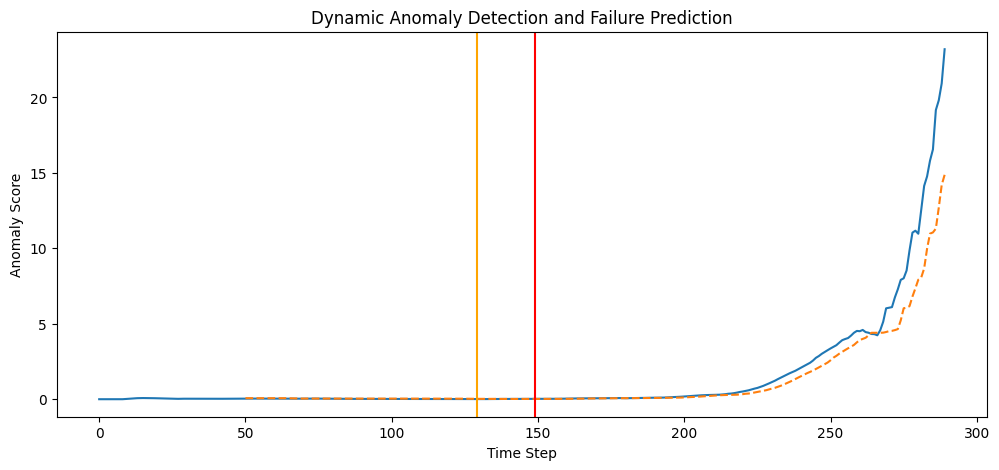

In [208]:
plt.figure(figsize=(12,5))

plt.plot(scores, label="Anomaly Score")

plt.plot(thresholds, linestyle="--", label="Dynamic Threshold")

if failure_idx is not None:
    plt.axvline(failure_idx, color="red", label="Failure")

if early_idx is not None:
    plt.axvline(early_idx, color="orange", label="Early Warning")

plt.title("Dynamic Anomaly Detection and Failure Prediction")

plt.xlabel("Time Step")
plt.ylabel("Anomaly Score")


In [209]:
# ==============================
# Health Indicator (Smoothed Score)
# ==============================

hi_window = 10

health_indicator = pd.Series(scores).rolling(
    window=hi_window,
    min_periods=1
).mean().values

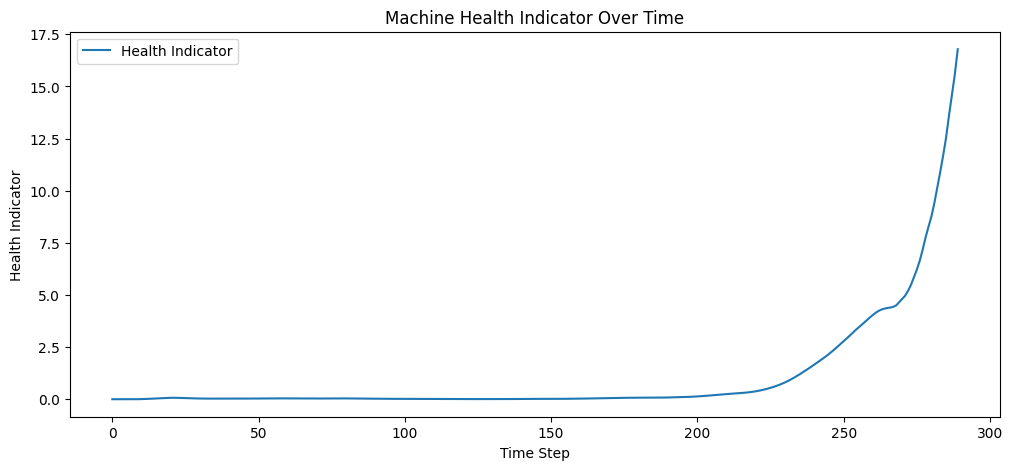

In [210]:
plt.figure(figsize=(12,5))

plt.plot(health_indicator, label="Health Indicator")

plt.title("Machine Health Indicator Over Time")

plt.xlabel("Time Step")
plt.ylabel("Health Indicator")

plt.legend()

plt.show()

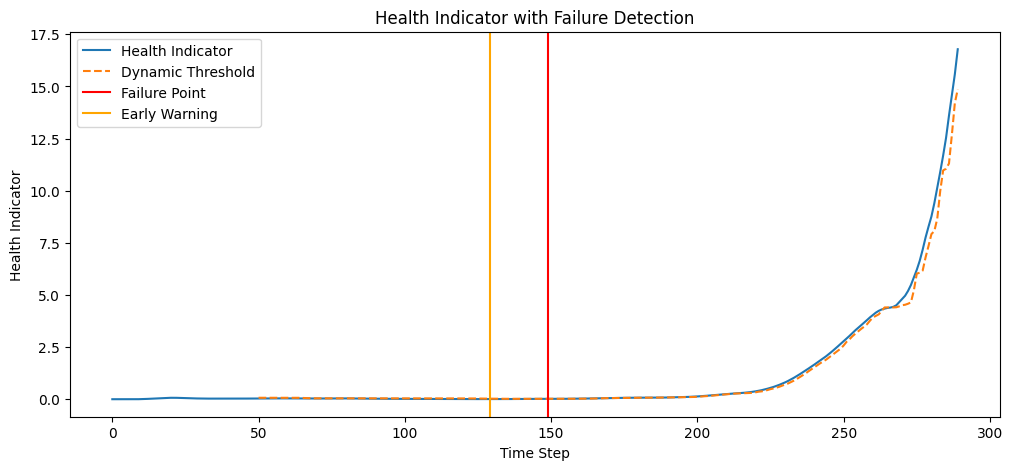

In [211]:
plt.figure(figsize=(12,5))

plt.plot(health_indicator, label="Health Indicator")

plt.plot(thresholds, linestyle="--", label="Dynamic Threshold")

if failure_idx is not None:
    plt.axvline(failure_idx, color="red", label="Failure Point")

if early_idx is not None:
    plt.axvline(early_idx, color="orange", label="Early Warning")

plt.title("Health Indicator with Failure Detection")

plt.xlabel("Time Step")
plt.ylabel("Health Indicator")

plt.legend()

plt.show()

In [212]:
# ==============================
# RUL Calculation
# ==============================

def compute_rul_curve(scores, failure_index):

    rul = []

    for t in range(len(scores)):

        if failure_index is None:
            rul.append(np.nan)
        else:
            remaining_life = failure_index - t

            if remaining_life < 0:
                remaining_life = 0

            rul.append(remaining_life)

    return np.array(rul)


rul_curve = compute_rul_curve(scores, failure_idx)

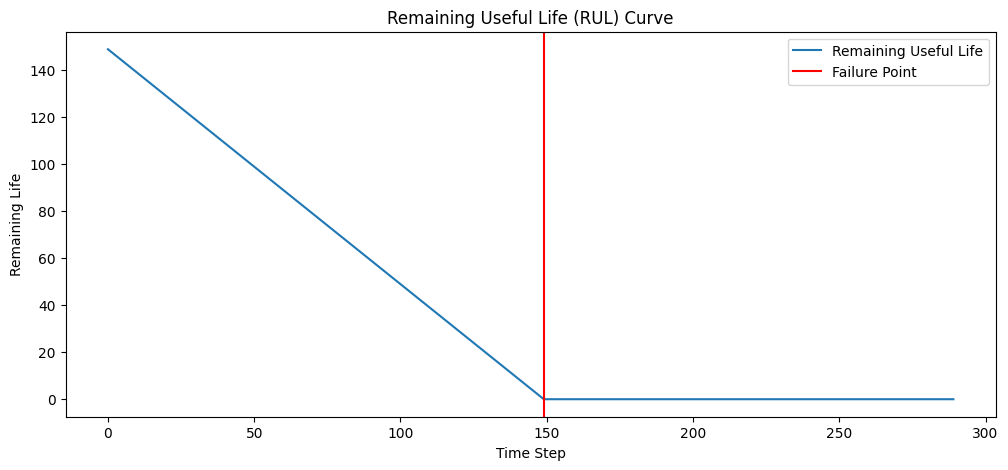

In [213]:
plt.figure(figsize=(12,5))

plt.plot(rul_curve, label="Remaining Useful Life")

if failure_idx is not None:
    plt.axvline(failure_idx, color="red", label="Failure Point")

plt.title("Remaining Useful Life (RUL) Curve")

plt.xlabel("Time Step")
plt.ylabel("Remaining Life")

plt.legend()

plt.show()

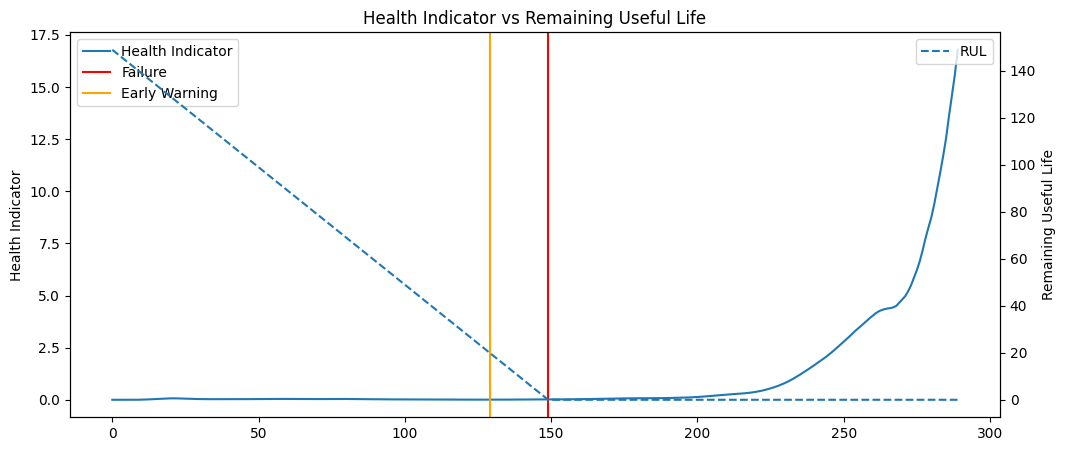

In [214]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(health_indicator, label="Health Indicator")
ax1.set_ylabel("Health Indicator")

if failure_idx is not None:
    ax1.axvline(failure_idx, color="red", label="Failure")

if early_idx is not None:
    ax1.axvline(early_idx, color="orange", label="Early Warning")


ax2 = ax1.twinx()

ax2.plot(rul_curve, linestyle="--", label="RUL")
ax2.set_ylabel("Remaining Useful Life")


ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("Health Indicator vs Remaining Useful Life")

plt.show()

In [215]:
def classify_health_state(health_indicator):

    states = []

    for hi in health_indicator:

        if hi < 0.4:
            states.append("NORMAL")

        elif hi < 0.7:
            states.append("DEGRADING")

        else:
            states.append("CRITICAL")

    return states


health_states = classify_health_state(health_indicator)

In [216]:
current_time = len(rul_curve) - 1

current_rul = rul_curve[current_time]

In [217]:
if failure_idx is not None and early_idx is not None:
    lead_time = failure_idx - early_idx
else:
    lead_time = None

In [218]:
def monitoring_dashboard(health_indicator, rul_curve, health_states):

    current_index = len(health_indicator) - 1

    status = health_states[current_index]

    current_hi = health_indicator[current_index]

    current_rul = rul_curve[current_index]

    print("\n===== MACHINE HEALTH MONITOR =====")

    print(f"Machine Status: {status}")

    print(f"Health Indicator: {current_hi:.3f}")

    print(f"Remaining Useful Life (RUL): {current_rul} cycles")

    if current_rul > 100:
        action = "System operating normally"

    elif current_rul > 50:
        action = "Monitor system closely"

    elif current_rul > 20:
        action = "Schedule maintenance"

    else:
        action = "Immediate maintenance required"

    print(f"Recommended Action: {action}")

    print("=================================\n")

In [219]:
## Sample Output
monitoring_dashboard(health_indicator, rul_curve, health_states)


===== MACHINE HEALTH MONITOR =====
Machine Status: CRITICAL
Health Indicator: 16.787
Remaining Useful Life (RUL): 0 cycles
Recommended Action: Immediate maintenance required



In [220]:
## Sample output Dataframe format
dashboard_df = pd.DataFrame({
    "Health Indicator": health_indicator,
    "Health State": health_states,
    "RUL": rul_curve
})

#print(dashboard_df.tail())
#print(dashboard_df.head())
dashboard_df.sample(10)

,Health Indicator,Health State,RUL
107,0.018242,NORMAL,42
163,0.042722,NORMAL,0
184,0.081010,NORMAL,0
135,0.014257,NORMAL,14
194,0.104640,NORMAL,0
5,0.006498,NORMAL,144
49,0.041127,NORMAL,100
46,0.037708,NORMAL,103
33,0.035641,NORMAL,116
75,0.044369,NORMAL,74


### Dataset Real time Evaluation

In [154]:
import time

def realtime_monitoring(data_sequences,
                        model,
                        scaler,
                        window_size,
                        failure_idx):

    print("\nStarting Real-Time Monitoring Simulation\n")

    hi_history = []
    rul_history = []

    for t in range(len(data_sequences)):

        window = data_sequences[t:t+1]

        # prediction
        pred = model.predict(window, verbose=0)

        # reconstruction error
        error = np.mean(np.square(window - pred))

        hi_history.append(error)

        # smooth health indicator
        hi_smoothed = pd.Series(hi_history).rolling(10, min_periods=1).mean().iloc[-1]

        # compute RUL
        if failure_idx is not None:
            rul = max(failure_idx - t, 0)
        else:
            rul = None

        rul_history.append(rul)

        # determine health state
        if hi_smoothed < 0.4:
            state = "NORMAL"

        elif hi_smoothed < 0.7:
            state = "DEGRADING"

        else:
            state = "CRITICAL"

        # dashboard output
        print("================================")
        print(f"Time Step: {t}")
        print(f"Health Indicator: {hi_smoothed:.4f}")
        print(f"Machine State: {state}")
        print(f"Remaining Useful Life: {rul}")
        print("================================\n")

        # simulate sensor delay
        time.sleep(0.2)

In [155]:
## Dataset Real time evaluation

realtime_monitoring(
    X_test,
    autoencoder,
    scaler,
    window_size,
    failure_idx
)


Starting Real-Time Monitoring Simulation

Time Step: 0
Health Indicator: 0.0086
Machine State: NORMAL
Remaining Useful Life: 152

Time Step: 1
Health Indicator: 0.0084
Machine State: NORMAL
Remaining Useful Life: 151

Time Step: 2
Health Indicator: 0.0085
Machine State: NORMAL
Remaining Useful Life: 150

Time Step: 3
Health Indicator: 0.0085
Machine State: NORMAL
Remaining Useful Life: 149

Time Step: 4
Health Indicator: 0.0085
Machine State: NORMAL
Remaining Useful Life: 148

Time Step: 5
Health Indicator: 0.0084
Machine State: NORMAL
Remaining Useful Life: 147

Time Step: 6
Health Indicator: 0.0084
Machine State: NORMAL
Remaining Useful Life: 146

Time Step: 7
Health Indicator: 0.0085
Machine State: NORMAL
Remaining Useful Life: 145

Time Step: 8
Health Indicator: 0.0087
Machine State: NORMAL
Remaining Useful Life: 144

Time Step: 9
Health Indicator: 0.0106
Machine State: NORMAL
Remaining Useful Life: 143

Time Step: 10
Health Indicator: 0.0148
Machine State: NORMAL
Remaining Useful

KeyboardInterrupt: 

In [188]:
# Dataset Real-time Evaluation - Dataframe updating table format

import time
results_data = []

for t in range(len(X_test)):

    sensor_window = X_test[t:t+1]

    prediction = autoencoder.predict(sensor_window, verbose=0)

    error = np.mean((sensor_window - prediction)**2)

    hi = error

    if hi < 0.4:
        state = "NORMAL"
    elif hi < 0.7:
        state = "DEGRADING"
    else:
        state = "CRITICAL"

    rul = max(failure_idx - t, 0)

    results_data.append({
                "time_step": t,
               # "sensor_value": sensor_value,
                "health_indicator": hi,
                "machine_state": state,
                "RUL": rul
            })

    results_data_df = pd.DataFrame(results_data)

            # LIVE UPDATE TABLE
    clear_output(wait=True)
    display(results_data_df.tail(10))

    time.sleep(0.15)

return results_data_df
    

,time_step,health_indicator,machine_state,RUL
4,4,0.008427,NORMAL,148
5,5,0.008311,NORMAL,147
6,6,0.008346,NORMAL,146
7,7,0.009153,NORMAL,145
8,8,0.009930,NORMAL,144
9,9,0.028037,NORMAL,143
10,10,0.050618,NORMAL,142
11,11,0.071005,NORMAL,141
12,12,0.084758,NORMAL,140
13,13,0.095682,NORMAL,139


KeyboardInterrupt: 

### Next steps - We are planning to make a visualization dashboard in streamlit 
- Real-time visulalization of of Anomaly score trend, 
- Real-time sensor value evaluation running log-table, 
- Captured & predicted failures with the RUL arranged priority wise.   

### Most of the software related work is done 


for now small scale asset can be improvised later 
- Hardware asset - any rotating asset 
- ex. Table Fan(most appropriate), ceiling fan, water pump(Hard)

### Synthetic Signal generator and evaluator

In [161]:
import numpy as np

def generate_vibration(t):

    base = np.sin(2*np.pi*5*t)

    noise = np.random.normal(0,0.05)

    degradation = 0.0005 * t

    signal = base + noise + degradation*np.random.randn()

    return signal

In [162]:
signal_stream = []

for t in range(1000):

    s = generate_vibration(t)

    signal_stream.append(s)

In [163]:
window_size = 20

signal_buffer = []

In [164]:
import pandas as pd

def extract_features(signal_window):

    arr = np.array(signal_window)

    features = [
        np.mean(arr),
        np.sqrt(np.mean(arr**2)),
        pd.Series(arr).skew(),
        pd.Series(arr).kurt()
    ]

    return np.array(features)

In [165]:
features = np.array([
    np.mean(window),
    np.sqrt(np.mean(np.square(window))),
    pd.Series(window).skew(),
    pd.Series(window).kurt()
])

In [166]:
import time
import pandas as pd
from IPython.display import display, clear_output

def run_demo(autoencoder, scaler):

    window_size = 20
    signal_buffer = []
    feature_buffer = []
    failure_time = 800   # simulated failure point

    print("\nStarting Predictive Maintenance Demo\n")

    results = []

    for t in range(1000):

        # simulate sensor
        sensor_value = generate_vibration(t)
        signal_buffer.append(sensor_value)

        if len(signal_buffer) >= window_size:

            window = signal_buffer[-window_size:]

            # extract features
            features = extract_features(window)

            # scale features
            features_df = pd.DataFrame([features], columns=merged_data.columns)
            features_scaled = scaler.transform(features_df)

            feature_buffer.append(features_scaled[0])

        if len(feature_buffer) >= window_size:

            sequence = np.array(feature_buffer[-window_size:]).reshape(1, window_size, 4)

            # model prediction
            pred = autoencoder.predict(sequence, verbose=0)

            error = np.mean((sequence - pred) ** 2)
            hi = error

            # machine state
            if hi < 0.3:
                state = "NORMAL"
            elif hi < 0.6:
                state = "DEGRADING"
            else:
                state = "CRITICAL"

            # simulated RUL
            rul = max(failure_time - t, 0)

            results.append({
                "time_step": t,
                "sensor_value": sensor_value,
                "health_indicator": hi,
                "machine_state": state,
                "RUL": rul
            })

            results_df = pd.DataFrame(results)

            # LIVE UPDATE TABLE
            clear_output(wait=True)
            display(results_df.tail(10))

            time.sleep(0.15)

    return results_df


In [167]:
results_df = run_demo(autoencoder, scaler)


Starting Predictive Maintenance Demo



C:\Users\Kartik\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


ValueError: X has 4 features, but MinMaxScaler is expecting 1 features as input.

In [168]:
import time
import pandas as pd
import numpy as np
from IPython.display import display, clear_output

def run_demo(autoencoder, scaler):


    window_size = 20
    signal_buffer = []
    feature_buffer = []
    failure_time = 800

    results = []
    smoothed_hi = None
    alpha = 0.2   # smoothing factor

    print("\nStarting Predictive Maintenance Demo\n")

    for t in range(1000):

        sensor_value = generate_vibration(t)
        signal_buffer.append(sensor_value)

        if len(signal_buffer) >= window_size:

            window = signal_buffer[-window_size:]
            features = extract_features(window)

            features_df = pd.DataFrame([features], columns=merged_data.columns)
            features_scaled = scaler.transform(features_df)

            feature_buffer.append(features_scaled[0])

        if len(feature_buffer) >= window_size:

            sequence = np.array(feature_buffer[-window_size:]).reshape(1, window_size, 4)

            pred = autoencoder.predict(sequence, verbose=0)

            error = np.mean((sequence - pred) ** 2)

            # Exponential smoothing
            if smoothed_hi is None:
                smoothed_hi = error
            else:
                smoothed_hi = alpha * error + (1 - alpha) * smoothed_hi

            hi = smoothed_hi

            if hi < 750:
                state = "NORMAL"
            elif hi < 900:
                state = "DEGRADING"
            else:
                state = "CRITICAL"

            rul = max(failure_time - t, 0)

            results.append({
                "time_step": t,
                "sensor_value": sensor_value,
                "health_indicator": hi,
                "machine_state": state,
                "RUL": rul
            })

            results_df = pd.DataFrame(results)

            clear_output(wait=True)
            display(results_df.tail(10))

            time.sleep(0.15)

    return results_df


In [169]:
results_df = run_demo(autoencoder, scaler)


Starting Predictive Maintenance Demo



C:\Users\Kartik\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


ValueError: X has 4 features, but MinMaxScaler is expecting 1 features as input.

In [170]:
import matplotlib.pyplot as plt 
from IPython.display import clear_output

In [172]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

def run_demo(autoencoder, scaler):


    window_size = 20
    signal_buffer = []
    feature_buffer = []
    failure_time = 800

    results = []

    smoothed_hi = None
    alpha = 0.2

    print("\nStarting Predictive Maintenance Demo\n")

    for t in range(1000):

        sensor_value = generate_vibration(t)
        signal_buffer.append(sensor_value)

    if len(signal_buffer) >= window_size:

        window = signal_buffer[-window_size:]
        features = extract_features(window)

        features_df = pd.DataFrame([features], columns=merged_data.columns)
        features_scaled = scaler.transform(features_df)

        feature_buffer.append(features_scaled[0])

        if len(feature_buffer) >= window_size:

            sequence = np.array(feature_buffer[-window_size:]).reshape(1,window_size,4)

            pred = autoencoder.predict(sequence, verbose=0)

            error = np.mean((sequence - pred)**2)

            if smoothed_hi is None:
                smoothed_hi = error
            else:
                smoothed_hi = alpha * error + (1-alpha) * smoothed_hi

            hi = smoothed_hi

            if hi < 750:
                state = "NORMAL"
            elif hi < 900:
                state = "DEGRADING"
            else:
                state = "CRITICAL"

            rul = max(failure_time - t, 0)

            results.append({
                "time": t,
                "signal": sensor_value,
                "HI": hi,
                "state": state,
                "RUL": rul
            })

            df = pd.DataFrame(results)

            clear_output(wait=True)

            plt.figure(figsize=(12,8))

            # SIGNAL
            plt.subplot(3,1,1)
            plt.plot(df["time"], df["signal"])
            plt.title("Sensor Vibration Signal")

            # HEALTH INDICATOR
            plt.subplot(3,1,2)
            plt.plot(df["time"], df["HI"])
            plt.title("Health Indicator")

            # RUL
            plt.subplot(3,1,3)
            plt.plot(df["time"], df["RUL"])
            plt.title("Remaining Useful Life")

            plt.tight_layout()
            plt.show()

            print("Current State:", state)
            print("Current RUL:", rul)

            time.sleep(0.15)

return df



IndentationError: expected an indented block (3285302375.py, line 10)

In [173]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

def run_demo(autoencoder, scaler, merged_data):
    # Configuration Constants
    window_size = 20
    signal_buffer = []
    feature_buffer = []
    failure_time = 800
    results = []
    
    # Smoothing parameters for the Health Indicator (HI)
    smoothed_hi = None
    alpha = 0.2

    print("\nStarting Predictive Maintenance Demo\n")

    for t in range(1000):
        # 1. Simulate data acquisition
        sensor_value = generate_vibration(t)
        signal_buffer.append(sensor_value)

        # 2. Check if we have enough data for feature extraction
        if len(signal_buffer) >= window_size:
            window = signal_buffer[-window_size:]
            features = extract_features(window)

            # 3. Scale features for the Autoencoder
            features_df = pd.DataFrame([features], columns=merged_data.columns)
            features_scaled = scaler.transform(features_df)
            feature_buffer.append(features_scaled[0])

            # 4. Check if we have enough features for a temporal sequence (LSTM/GRU)
            if len(feature_buffer) >= window_size:
                # Shape: (1, window_size, number_of_features)
                num_features = features_scaled.shape[1]
                sequence = np.array(feature_buffer[-window_size:]).reshape(1, window_size, num_features)

                # 5. Predict and calculate Reconstruction Error (Anomaly Score)
                pred = autoencoder.predict(sequence, verbose=0)
                error = np.mean((sequence - pred)**2)

                # 6. Apply Exponential Moving Average (EMA) smoothing
                if smoothed_hi is None:
                    smoothed_hi = error
                else:
                    smoothed_hi = alpha * error + (1 - alpha) * smoothed_hi
                
                hi = smoothed_hi

                # 7. Determine Machine State based on HI thresholds
                if hi < 750:
                    state = "NORMAL"
                elif hi < 900:
                    state = "DEGRADING"
                else:
                    state = "CRITICAL"

                # 8. Calculate Remaining Useful Life (RUL)
                rul = max(failure_time - t, 0)

                # 9. Store results for plotting
                results.append({
                    "time": t,
                    "signal": sensor_value,
                    "HI": hi,
                    "state": state,
                    "RUL": rul
                })

                df = pd.DataFrame(results)

                # 10. Real-time Visualization
                clear_output(wait=True)
                plt.figure(figsize=(12, 8))

                # Plot 1: Raw Sensor Signal
                plt.subplot(3, 1, 1)
                plt.plot(df["time"], df["signal"], color='blue')
                plt.title("Sensor Vibration Signal")
                plt.grid(True)

                # Plot 2: Health Indicator (Reconstruction Error)
                plt.subplot(3, 1, 2)
                plt.plot(df["time"], df["HI"], color='orange')
                plt.axhline(y=750, color='green', linestyle='--', label='Degrading Threshold')
                plt.axhline(y=900, color='red', linestyle='--', label='Critical Threshold')
                plt.title("Health Indicator (Autoencoder Error)")
                plt.legend()
                plt.grid(True)

                # Plot 3: Remaining Useful Life
                plt.subplot(3, 1, 3)
                plt.plot(df["time"], df["RUL"], color='green')
                plt.title("Remaining Useful Life (RUL)")
                plt.xlabel("Time Steps")
                plt.grid(True)

                plt.tight_layout()
                plt.show()

                print(f"Time: {t} | State: {state} | Current RUL: {rul}")
                
                # Control the speed of the simulation
                time.sleep(0.15)

    return df

# Note: Ensure these functions are defined before calling run_demo
def generate_vibration(t):
    # Placeholder for your vibration logic
    return np.sin(t/10) + np.random.normal(0, 0.1)

def extract_features(window):
    # Placeholder for feature extraction (Mean, Std, RMS, etc.)
    # Must return a list/array matching merged_data columns
    return [np.mean(window), np.std(window), np.max(window), np.min(window)]

In [175]:
results_df = run_demo(autoencoder,scaler,merged_data)


Starting Predictive Maintenance Demo



C:\Users\Kartik\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


ValueError: X has 4 features, but MinMaxScaler is expecting 1 features as input.

In [181]:
def run_demo(autoencoder, scaler, merged_data):
    window_size = 20
    feature_buffer = []
    failure_time = len(merged_data)  # Assuming end of data is failure
    results = []

    smoothed_hi = None
    alpha = 0.2

    print("\nStarting Predictive Maintenance Demo with Dataset\n")

    # Iterate directly through the pre-processed features
    for t in range(len(merged_data)):
        
        # Get the feature row as a scaled array
        current_features = merged_data.iloc[t].values
        features_scaled = scaler.transform([current_features])
        feature_buffer.append(features_scaled[0])

        if len(feature_buffer) >= window_size:
            # Create the sequence for the Autoencoder
            sequence = np.array(feature_buffer[-window_size:]).reshape(1, window_size, merged_data.shape[1])

            # Predict and calculate reconstruction error
            pred = autoencoder.predict(sequence, verbose=0)
            error = np.mean((sequence - pred)**2)

            # EMA Smoothing
            if smoothed_hi is None:
                smoothed_hi = error
            else:
                smoothed_hi = alpha * error + (1 - alpha) * smoothed_hi
            
            hi = smoothed_hi

            # Threshold logic
            if hi < 750:
                state = "NORMAL"
            elif hi < 900:
                state = "DEGRADING"
            else:
                state = "CRITICAL"

            rul = max(failure_time - t, 0)

            results.append({
                "time": t,
                "HI": hi,
                "state": state,
                "RUL": rul
            })


             df = pd.DataFrame(results)

                clear_output(wait=True)

                plt.figure(figsize=(12,8))

                # SIGNAL
                plt.subplot(3,1,1)
                plt.plot(df["time"], df["signal"])
                plt.title("Sensor Vibration Signal")

                # HEALTH INDICATOR
                plt.subplot(3,1,2)
                plt.plot(df["time"], df["HI"])
                plt.title("Health Indicator")

                # RUL
                plt.subplot(3,1,3)
                plt.plot(df["time"], df["RUL"])
                plt.title("Remaining Useful Life")

                plt.tight_layout()
                plt.show()

                print("Current State:", state)
                print("Current RUL:", rul)

                time.sleep(0.15)

    return df

IndentationError: unexpected indent (2666946208.py, line 56)

In [186]:
def run_demo(autoencoder, scaler, merged_data):
    window_size = 20
    feature_buffer = []
    failure_time = len(X_test)  # Assuming end of data is failure
    results = []

    smoothed_hi = None
    alpha = 0.2

    print("\nStarting Predictive Maintenance Demo with Dataset\n")

    # Iterate directly through the pre-processed features
    for t in range(len(X_test)):
        
        # Get the feature row as a scaled array
        current_features = X_test.iloc[t].values
        features_scaled = scaler.transform([current_features])
        feature_buffer.append(features_scaled[0])

        if len(feature_buffer) >= window_size:
            # Create the sequence for the Autoencoder
            sequence = np.array(feature_buffer[-window_size:]).reshape(1, window_size, merged_data.shape[1])

            # Predict and calculate reconstruction error
            pred = autoencoder.predict(sequence, verbose=0)
            error = np.mean((sequence - pred)**2)

            # EMA Smoothing
            if smoothed_hi is None:
                smoothed_hi = error
            else:
                smoothed_hi = alpha * error + (1 - alpha) * smoothed_hi
            
            hi = smoothed_hi

            # Threshold logic
            if hi < 750:
                state = "NORMAL"
            elif hi < 900:
                state = "DEGRADING"
            else:
                state = "CRITICAL"

            rul = max(failure_time - t, 0)

            results.append({
                "time": t,
                "HI": hi,
                "state": state,
                "RUL": rul
            })

            df = pd.DataFrame(results)

            clear_output(wait=True)

            plt.figure(figsize=(12, 8))

            # HEALTH INDICATOR
            plt.subplot(2, 1, 1)
            plt.plot(df["time"], df["HI"])
            plt.title("Health Indicator")

            # RUL
            plt.subplot(2, 1, 2)
            plt.plot(df["time"], df["RUL"])
            plt.title("Remaining Useful Life")

            plt.tight_layout()
            plt.show()

            print("Current State:", state)
            print("Current RUL:", rul)

            time.sleep(0.15)

    return df

In [187]:
results_df = run_demo(autoencoder,scaler,merged_data)


Starting Predictive Maintenance Demo with Dataset



AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [ ]:
import time
results_data = []

for t in range(len(X_test)):

    sensor_window = X_test[t:t+1]

    prediction = autoencoder.predict(sensor_window, verbose=0)

    error = np.mean((sensor_window - prediction)**2)

    hi = error

    if hi < 0.4:
        state = "NORMAL"
    elif hi < 0.7:
        state = "DEGRADING"
    else:
        state = "CRITICAL"

    rul = max(failure_idx - t, 0)

    results_data.append({
                "time_step": t,
               # "sensor_value": sensor_value,
                "health_indicator": hi,
                "machine_state": state,
                "RUL": rul
            })

    results_data_df = pd.DataFrame(results_data)

            # LIVE UPDATE TABLE
    clear_output(wait=True)
    display(results_data_df.tail(10))

    time.sleep(0.15)

return results_data_df

In [221]:
# Working Real time plot 
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

def run_dataset_demo(autoencoder, scaler, dataset):

    window_size = 20
    feature_buffer = []
    results = []

    failure_time = len(dataset)

    smoothed_hi = None
    alpha = 0.2

    print("\nStarting Predictive Maintenance Dataset Demo\n")

    for t in range(len(dataset)):

        # Extract features for the current timestamp and reshape for the scaler
        features = dataset.iloc[t].values.reshape(1, -1)

        # scale features
        features_scaled = scaler.transform(features)

        feature_buffer.append(features_scaled[0])

        if len(feature_buffer) >= window_size:

            # Shape for Autoencoder: (1, window_size, number_of_features)
            sequence = np.array(feature_buffer[-window_size:]).reshape(1, window_size, features_scaled.shape[1])

            pred = autoencoder.predict(sequence, verbose=0)

            # Calculate Reconstruction Error
            error = np.mean((sequence - pred)**2)

            # EMA Smoothing
            if smoothed_hi is None:
                smoothed_hi = error
            else:
                smoothed_hi = alpha * error + (1 - alpha) * smoothed_hi

            hi = smoothed_hi

            # Adjust thresholds based on your model's error range
            if hi < 750:
                state = "NORMAL"
            elif hi < 900:
                state = "DEGRADING"
            else:
                state = "CRITICAL"

            rul = max(failure_time - t, 0)

            results.append({
                "time": t,
                "HI": hi,
                "state": state,
                "RUL": rul
            })

            df = pd.DataFrame(results)

            clear_output(wait=True)

            plt.figure(figsize=(12, 8))

            # HEALTH INDICATOR PLOT
            plt.subplot(2, 1, 1)
            plt.plot(df["time"], df["HI"])
            plt.title("Health Indicator")

            # RUL PLOT
            plt.subplot(2, 1, 2)
            plt.plot(df["time"], df["RUL"])
            plt.title("Remaining Useful Life")

            plt.tight_layout()
            plt.show()

            print("Current State:", state)
            print("Current RUL:", rul)

            time.sleep(0.05)

    return df

In [223]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(merged_data)

MinMaxScaler()

In [224]:
results_df = run_dataset_demo(autoencoder, scaler, merged_data)

KeyboardInterrupt: 